<a href="https://colab.research.google.com/github/alfanugraha/climate-risk-adaptation/blob/main/climate_risk_adaptation_ai_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Climate Risk & Adaptation
## Climate Risk Assessment — Google Colab Skeleton

Notebook di dalam analisis ini seluruhnya menggunakan **Python**,
dengan pendekatan **prompt-driven**, di mana GenAI/LLM digunakan sebagai mitra pemrograman.

**Dataset:** TerraClim, data iklim spatio-temporal untuk wilayah Indonesia, dengan pilihan variabel suhu maksimum & minimum, dan curah hujan

<https://climate.northwestknowledge.net/TERRACLIMATE/index_directDownloads.php>

**Satuan waktu:** Bulanan (monthly)

**Asumsi kunci:** Tren iklim dapat mempengaruhi risiko banjir secara signifikan maupun wilayah yang mengalami panas atau kering dalam satu kurun waktu

---
### Cara menggunakan notebook ini

1. Copy prompt pada cell yang tersedia ke LLM (Deepseek/ChatGPT)
2. Paste hasil dari AI ke dalam cell notebook
3. Jalankan setiap cell secara berurutan (Shift+Enter)
4. Jika ada error, paste error tersebut ke AI untuk diperbaiki

> **Tips:** Selalu minta AI untuk menjelaskan kode yang dihasilkan sebelum menjalankannya!

# 0. Setup

## Prompt (copy/paste)

```
Persona:
Kamu adalah analis risiko iklim senior di bank komersial Indonesia.

Task:
- Tulis sebuah cell setup yang siap digunakan di Colab: termasuk import library,
  konfigurasi plotting dasar, dan helper untuk reproducibility.
- Jika ada package yang belum terinstall, tunjukkan cara menjalankan pip install di cell setup.

Constraints:
- Gunakan numpy, pandas, geopandas, xarray, rioxarray, rasterio, matplotlib, seaborn, scikit-learn, netCDF4, pmdarima, statsmodels.

Verification:
- Print versi library dan pesan sederhana bahwa library siap digunakan.
```

In [ ]:
# =========================
# INSTALL REQUIRED PACKAGES
# =========================
# Jalankan ini jika environment masih bersih (Colab default biasanya perlu ini)

!pip install -q numpy pandas geopandas xarray netCDF4 rioxarray rasterio matplotlib seaborn scikit-learn pmdarima statsmodels

# =========================
# IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import netCDF4 as nc
import rioxarray as rxr
import rasterio

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import pmdarima as pm

import random
import os
import warnings

# =========================
# REPRODUCIBILITY SETTINGS
# =========================
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# =========================
# WARNING & DISPLAY SETTINGS
# =========================
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# =========================
# PLOTTING CONFIGURATION
# =========================
plt.style.use("seaborn-v0_8")

sns.set(
    style="whitegrid",
    context="talk",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# =========================
# VERSION CHECK
# =========================
print("=== LIBRARY VERSIONS ===")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"geopandas    : {gpd.__version__}")
print(f"xarray       : {xr.__version__}")
print(f"netCDF4      : {nc.__version__}")
print(f"rioxarray    : {rxr.__version__}")
print(f"rasterio     : {rasterio.__version__}")
print(f"matplotlib   : {plt.matplotlib.__version__}")
print(f"seaborn      : {sns.__version__}")
print(f"scikit-learn : {__import__('sklearn').__version__}")
print(f"statsmodels  : {sm.__version__}")
print(f"pmdarima     : {pm.__version__}")

print("\n✅ Semua library berhasil di-load. Environment siap untuk analisis risiko iklim.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.1 MB/s eta 0:00:00
=== LIBRARY VERSIONS ===
numpy        : 2.0.2
pandas       : 2.2.2
geopandas    : 1.1.3
xarray       : 2026.2.0
netCDF4      : 1.7.4
rioxarray    : 0.22.0
rasterio     : 1.5.0
matplotlib   : 3.10.0
seaborn      : 0.13.2
scikit-learn : 1.6.1
statsmodels  : 0.14.6
pmdarima     : 2.1.1

✅ Semua library berhasil di-load. Environment siap untuk analisis risiko iklim.


# 1. Persiapan Data

## Prompt (optional)

```
Task:
- Tulis sebuah cell kode python yang siap digunakan di Colab: buat folder "data"
- Download zip file dari google drive id berikut dan unzip ke folder "data":
   - Batas provinsi dengan id 1Q-eLMTysb9J_xa0LVg3TN76G45AQTRI0, folder "batas_provinsi"
   - Batas kabupaten/kota dengan id 18rELsvN_SXuqZ-BFRs6eRREkeYIXSEDY, folder "batas_kabupaten"
   - Data iklim TerraClimate dengan id 1TTJ212rFfpZl6Qnbrj2zkIE7PVthGEiY, folder "iklim"
```

In [ ]:
# =========================
# SETUP FOLDER
# =========================
import os
import zipfile

BASE_DIR = "data"
os.makedirs(BASE_DIR, exist_ok=True)

# =========================
# INSTALL TOOL DOWNLOAD GDRIVE
# =========================
# !pip install -q gdown

import gdown

# =========================
# FUNCTION DOWNLOAD + UNZIP
# =========================
def download_and_unzip(gdrive_id, output_folder, zip_name):
    output_path = os.path.join(BASE_DIR, zip_name)
    extract_path = os.path.join(BASE_DIR, output_folder)

    os.makedirs(extract_path, exist_ok=True)

    # Download
    url = f"https://drive.google.com/uc?id={gdrive_id}"
    print(f"Downloading {zip_name}...")
    gdown.download(url, output_path, quiet=False)

    # Unzip
    print(f"Extracting to {extract_path}...")
    with zipfile.ZipFile(output_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"Selesai: {output_folder}\n")

# =========================
# DOWNLOAD DATA
# =========================

# 1. Batas Provinsi
download_and_unzip(
    gdrive_id="1Q-eLMTysb9J_xa0LVg3TN76G45AQTRI0",
    output_folder="batas_provinsi",
    zip_name="batas_provinsi.zip"
)

# 2. Batas Kabupaten/Kota
download_and_unzip(
    gdrive_id="18rELsvN_SXuqZ-BFRs6eRREkeYIXSEDY",
    output_folder="batas_kabupaten",
    zip_name="batas_kabupaten.zip"
)

# 3. Data Iklim TerraClimate
download_and_unzip(
    gdrive_id="1TTJ212rFfpZl6Qnbrj2zkIE7PVthGEiY",
    output_folder="iklim",
    zip_name="iklim.zip"
)

print("✅ Semua data berhasil di-download dan diekstrak ke folder 'data'")

## Peta Batas Provinsi di Indonesia

Unduh dengan menjalankan perintah cell di bawah

In [ ]:
!gdown 1Q-eLMTysb9J_xa0LVg3TN76G45AQTRI0

Downloading...
From (original): https://drive.google.com/uc?id=1Q-eLMTysb9J_xa0LVg3TN76G45AQTRI0
From (redirected): https://drive.google.com/uc?id=1Q-eLMTysb9J_xa0LVg3TN76G45AQTRI0&confirm=t&uuid=6e3741fa-6430-4183-99a6-503791270e73
To: /content/batas_provinsi.zip
100% 125M/125M [00:03<00:00, 40.4MB/s]


Unzip data

In [ ]:
!unzip batas_provinsi.zip -d batas_provinsi

Archive:  batas_provinsi.zip
Created by ZIP Extractor v4.76 (https://zipextractor.app)
  inflating: batas_provinsi/Provinsi_Kemdagri.dbf  
  inflating: batas_provinsi/Provinsi_Kemdagri.shp  
  inflating: batas_provinsi/Provinsi_Kemdagri.shx  
  inflating: batas_provinsi/Provinsi_Kemdagri.cpg  
  inflating: batas_provinsi/Provinsi_Kemdagri.prj  
  inflating: batas_provinsi/Provinsi_Kemdagri.qmd  


## Peta Batas Kabupaten/Kota di Indonesia

Unduh dengan menjalankan perintah cell di bawah

In [ ]:
!gdown 18rELsvN_SXuqZ-BFRs6eRREkeYIXSEDY

Downloading...
From (original): https://drive.google.com/uc?id=18rELsvN_SXuqZ-BFRs6eRREkeYIXSEDY
From (redirected): https://drive.google.com/uc?id=18rELsvN_SXuqZ-BFRs6eRREkeYIXSEDY&confirm=t&uuid=7332ed4f-ef70-4c71-b835-8cdaad65a0f9
To: /content/batas_kabkot.zip
100% 152M/152M [00:03<00:00, 38.3MB/s]


Unzip data peta tersebut

In [ ]:
!unzip batas_kabkot.zip -d batas_kabkot

Archive:  batas_kabkot.zip
Created by ZIP Extractor v4.76 (https://zipextractor.app)
  inflating: batas_kabkot/Batas Kabupaten Kemendagri 2024.shp  
  inflating: batas_kabkot/Batas Kabupaten Kemendagri 2024.dbf  
  inflating: batas_kabkot/Batas Kabupaten Kemendagri 2024.shx  
  inflating: batas_kabkot/Batas Kabupaten Kemendagri 2024.cpg  
  inflating: batas_kabkot/Batas Kabupaten Kemendagri 2024.prj  


## Peta Iklim di Indonesia

Unduh dengan menjalankan perintah cell di bawah

In [ ]:
!gdown 1TTJ212rFfpZl6Qnbrj2zkIE7PVthGEiY

Downloading...
From: https://drive.google.com/uc?id=1TTJ212rFfpZl6Qnbrj2zkIE7PVthGEiY
To: /content/iklim.zip
100% 20.7M/20.7M [00:00<00:00, 41.6MB/s]


Unzip data iklim

In [ ]:
!unzip iklim.zip -d iklim

Archive:  iklim.zip
Created by ZIP Extractor v4.76 (https://zipextractor.app)
  inflating: iklim/TerraClimate_tmin_2025_IDN.nc  
  inflating: iklim/TerraClimate_tmin_2024_IDN.nc  
  inflating: iklim/TerraClimate_tmin_2023_IDN.nc  
  inflating: iklim/TerraClimate_tmin_2022_IDN.nc  
  inflating: iklim/TerraClimate_tmin_2021_IDN.nc  
  inflating: iklim/TerraClimate_tmax_2025_IDN.nc  
  inflating: iklim/TerraClimate_tmax_2024_IDN.nc  
  inflating: iklim/TerraClimate_tmax_2023_IDN.nc  
  inflating: iklim/TerraClimate_tmax_2022_IDN.nc  
  inflating: iklim/TerraClimate_tmax_2021_IDN.nc  
  inflating: iklim/TerraClimate_ppt_2025_IDN.nc  
  inflating: iklim/TerraClimate_ppt_2024_IDN.nc  
  inflating: iklim/TerraClimate_ppt_2023_IDN.nc  
  inflating: iklim/TerraClimate_ppt_2022_IDN.nc  
  inflating: iklim/TerraClimate_ppt_2021_IDN.nc  


# Eksplorasi Data

Load dataset yang sudah diunduh dan lakukan analisis data sederhana

Prompt (copy/paste)

```
Task:
Tulis kode python untuk:
1. Load batas wilayah administrasi Indonesia menggunakan shapefile di path
   /content/data/batas_provinsi/Provinsi_Kemdagri.shp (ADM1)
2. Konversi ke EPSG:4326
3. Buat batas nasional (ADM0) dengan metode dissolve
4. Plot keduanya dalam satu peta dengan border berwarna abu-abu untuk ADM1 dan bold untuk ADM0
5. Tambahkan label nama provinsi pada peta
6. Tingkatkan kualitas visualisasi (warna, styling, tampilan lebih menarik)

Constraints:
- Gunakan geopandas, dan matplotlib
- Buat kode tetap sederhana dan mudah dibaca
- WAJIB simpan hasil ke variabel bernama: gdf_adm1 (untuk ADM1) dan gdf_adm0 (untuk ADM0)
  Nama variabel ini akan digunakan oleh section lain, jangan diganti.
```

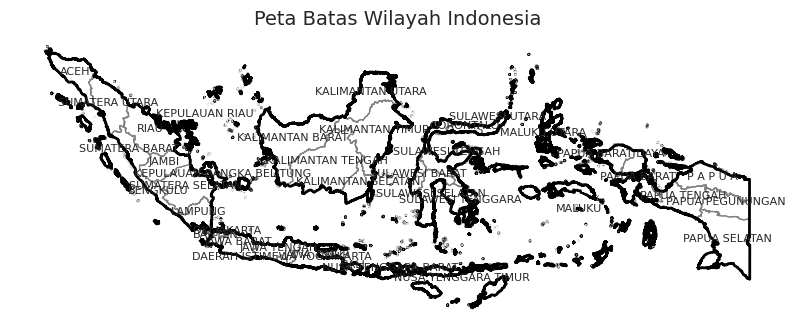

In [ ]:
# =========================
# LOAD SHAPEFILE (ADM1)
# =========================
import geopandas as gpd
import matplotlib.pyplot as plt

# Path shapefile
shp_path = "/content/batas_provinsi/Provinsi_Kemdagri.shp"

# Load data
gdf = gpd.read_file(shp_path)

# =========================
# CONVERT CRS TO EPSG:4326
# =========================
gdf = gdf.to_crs(epsg=4326)

# =========================
# CREATE NATIONAL BOUNDARY (ADM0)
# =========================
gdf_adm0 = gdf.dissolve()

# =========================
# PLOT MAP
# =========================
fig, ax = plt.subplots(figsize=(10, 10))

# Plot ADM1 (provinsi)
gdf.plot(ax=ax, edgecolor='gray', facecolor='none', linewidth=0.8)

# Plot ADM0 (nasional, lebih tebal)
gdf_adm0.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2)

# =========================
# ADD PROVINCE LABELS
# =========================
# Asumsi nama kolom provinsi = 'PROVINSI'
for idx, row in gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row['nama_prop'],
        fontsize=8,
        ha='center'
    )

# =========================
# FINAL TOUCH
# =========================
ax.set_title("Peta Batas Wilayah Indonesia", fontsize=14)
ax.axis('off')

plt.show()

## Data suhu

## Prompt (copy/paste)

```
Task:
Tulis kode python untuk:
1. Baca multi-file NetCDF untuk suhu maksimum (tmax) dan minumum (tmin) di path data/iklim
2. Hitung suhu rata-rata bulanan
3. Gunakan batas wilayah Indonesia sebagai referensi jika diperlukan
4. Hitung rata-rata suhu tahunan
5. Buat grafik tren suhu tahunan

Constraints:
- Gunakan xarray, rioxarray, dan matplotlib
- Buat kode tetap sederhana dan mudah dibaca
```

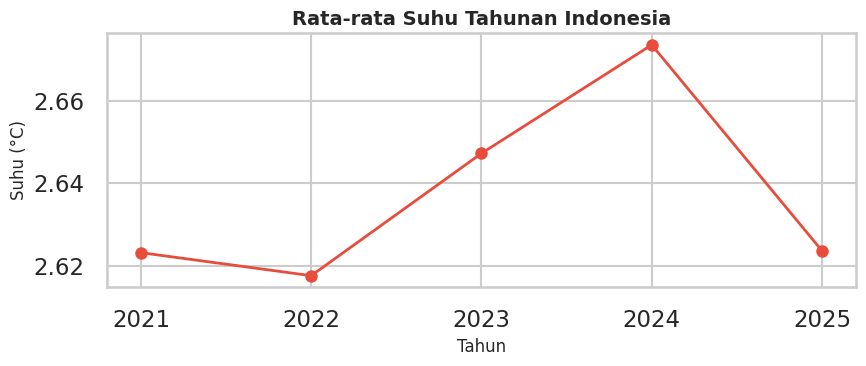

 year  temp_mean
 2021   2.623204
 2022   2.617636
 2023   2.647221
 2024   2.673465
 2025   2.623678

✅ Annual temperature successfully computed


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# =========================
# 1. BACA FILE NETCDF SUHU
# =========================

data_path = "/content/iklim"

# Asumsi file mengandung kata 'tmax' dan 'tmin'
ds_tmax = xr.open_mfdataset(f"{data_path}/*tmax*.nc", combine='by_coords')
ds_tmin = xr.open_mfdataset(f"{data_path}/*tmin*.nc", combine='by_coords')

tmax = ds_tmax["tmax"].squeeze(drop=True)   # (time, lat, lon)
tmin = ds_tmin["tmin"].squeeze(drop=True)

# =========================
# 2. SUHU RATA-RATA BULANAN
# =========================

# TerraClimate skala 0.1 °C → bagi 10
tavg_monthly = (tmax + tmin) / 2 / 10
tavg_monthly.name = "tavg"

# =========================
# 3. CLIP KE WILAYAH INDONESIA
# =========================

tavg_monthly = (
    tavg_monthly
    .rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    .rio.write_crs("EPSG:4326")
    .rio.clip(gdf_adm0.geometry, gdf_adm0.crs, drop=True, all_touched=True)
)

# =========================
# 4. AGREGASI TAHUNAN
# =========================

tavg_annual = tavg_monthly.resample(time="YE").mean()   # mean per tahun

# Rata-rata spasial per tahun
temp_annual = (
    tavg_annual
    .mean(dim=["lat", "lon"])
    .to_pandas()
    .rename("temp_mean")
)
temp_annual.index = temp_annual.index.year
temp_annual = temp_annual.reset_index().rename(columns={"time": "year"})

# =========================
# 5. PLOT TREN TAHUNAN
# =========================
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(temp_annual["year"], temp_annual["temp_mean"],
        marker="o", color="#e74c3c", linewidth=2)
ax.set_title("Rata-rata Suhu Tahunan Indonesia", fontweight="bold")
ax.set_xlabel("Tahun"); ax.set_ylabel("Suhu (°C)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

print(temp_annual.to_string(index=False))
print("\n✅ Annual temperature successfully computed")

Prompt (copy/paste)

```
Task:
Plot peta rata-rata suhu tahunan secara keseluruhan
```

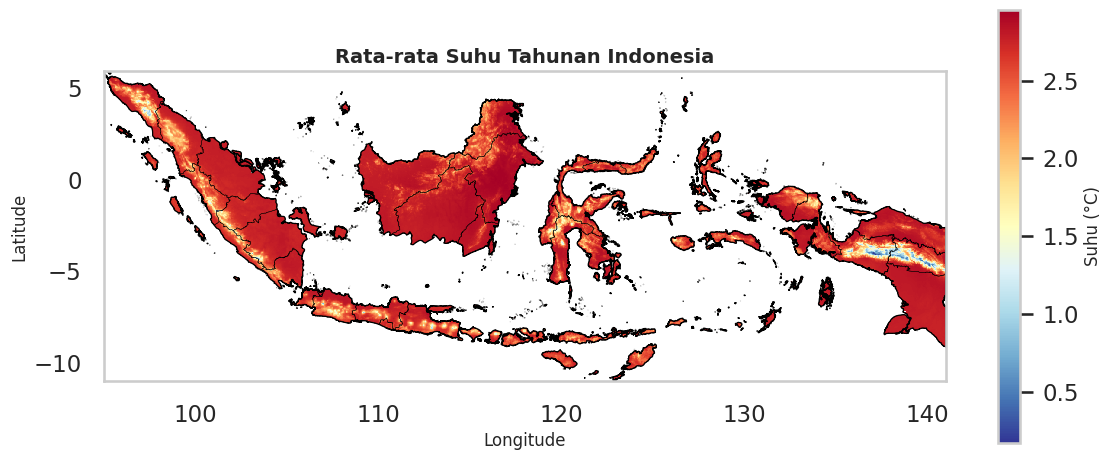

In [ ]:
# Rata-rata seluruh periode
annual_mean_temp = tavg_annual.mean(dim="time")

fig, ax = plt.subplots(figsize=(12, 5))
annual_mean_temp.plot(ax=ax, cmap="RdYlBu_r",
                      cbar_kwargs={"label": "Suhu (°C)"})
gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.3)
gdf_adm0.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.9)
ax.set_title("Rata-rata Suhu Tahunan Indonesia", fontweight="bold")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()

## Data curah hujan

```
Task:
Lakukan hal yang sama untuk data curah hujan
```

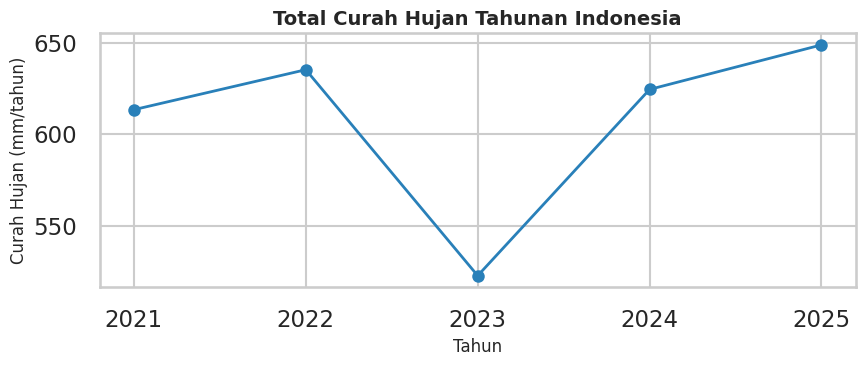

 year  precip_mm
 2021 613.593313
 2022 635.519010
 2023 522.508794
 2024 624.699014
 2025 649.144554

✅ Annual precipitation series ready


In [ ]:
# =========================
# 1. BACA FILE NETCDF CURAH HUJAN
# =========================


data_path = "/content/iklim"

ds_ppt = xr.open_mfdataset(f"{data_path}/*ppt*.nc", combine='by_coords')
ppt_raw = ds_ppt["ppt"].squeeze(drop=True)   # unit: mm/bulan

# =========================
# 2. CLIP KE INDONESIA
# =========================

ppt_monthly = (
    ppt_raw
    .rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    .rio.write_crs("EPSG:4326")
    .rio.clip(gdf_adm0.geometry, gdf_adm0.crs, drop=True, all_touched=True)
)
ppt_monthly.name = "ppt"

# =========================
# 3. TOTAL TAHUNAN (sum, bukan mean)
# =========================

ppt_annual = ppt_monthly.resample(time="YE").sum()

# Rata-rata spasial nasional per tahun
ppt_annual_mean = (
    ppt_annual
    .mean(dim=["lat", "lon"])
    .to_pandas()
    .rename("precip_mm")
)
ppt_annual_mean.index = ppt_annual_mean.index.year
ppt_annual_df = ppt_annual_mean.reset_index().rename(columns={"time": "year"})

# =========================
# 4. PLOT TREN TAHUNAN
# =========================

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ppt_annual_df["year"], ppt_annual_df["precip_mm"],
        marker="o", color="#2980b9", linewidth=2)
ax.set_title("Total Curah Hujan Tahunan Indonesia", fontweight="bold")
ax.set_xlabel("Tahun"); ax.set_ylabel("Curah Hujan (mm/tahun)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

print(ppt_annual_df.to_string(index=False))
print("\n✅ Annual precipitation series ready")

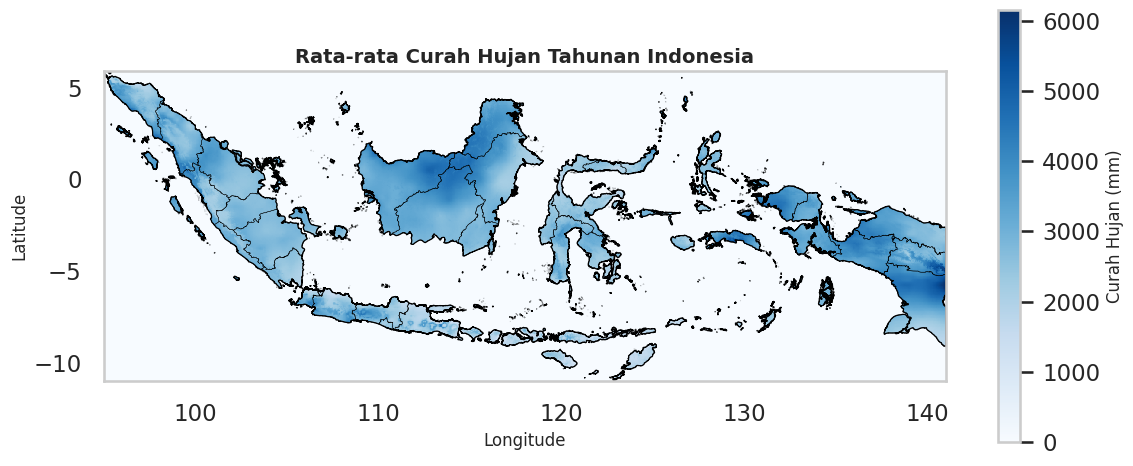

In [ ]:
annual_mean_ppt = ppt_annual.mean(dim="time")

fig, ax = plt.subplots(figsize=(12, 5))
annual_mean_ppt.plot(ax=ax, cmap="Blues",
                     cbar_kwargs={"label": "Curah Hujan (mm)"})
gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.3)
gdf_adm0.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.9)
ax.set_title("Rata-rata Curah Hujan Tahunan Indonesia", fontweight="bold")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()

## Stacking peta suhu dan curah hujan

```
Task:
- Gabungkan (stack) array suhu dan curah hujan rata-rata ke dalam satu DataFrame
  dengan kolom koordinat (x, y) dan nilai kedua variabel (suhu, curah_hujan)
- Siapkan untuk visualisasi bivariat
```

In [ ]:
# =========================
# 1. KONVERSI KE DATAFRAME 2D
# =========================

df_suhu = (
    annual_mean_temp
    .to_dataframe(name="suhu")
    .reset_index()
    .dropna(subset=["suhu"])
    .rename(columns={"lon": "x", "lat": "y"})
)

df_hujan = (
    annual_mean_ppt
    .to_dataframe(name="curah_hujan")
    .reset_index()
    .dropna(subset=["curah_hujan"])
    .rename(columns={"lon": "x", "lat": "y"})
)

# =========================
# 2. GABUNGKAN (MERGE BY KOORDINAT)
# =========================

climate_df = (
    df_suhu[["x", "y", "suhu"]]
    .merge(df_hujan[["x", "y", "curah_hujan"]], on=["x", "y"])
    .dropna()
    .reset_index(drop=True)
)

print(climate_df.head())
print(f"\nShape: {climate_df.shape}")
print(climate_df.describe().round(2))
print("\n✅ Raster stack ready for bivariate visualization")

           x         y      suhu  curah_hujan
0  95.229167  5.895833  2.722417      2619.40
1  95.270833  5.895833  2.781417      2371.78
2  95.312500  5.895833  2.789833      2396.24
3  95.354167  5.895833  2.779917      2449.66
4  95.229167  5.854167  2.721833      2617.86

Shape: (96428, 4)
              x         y      suhu  curah_hujan
count  96428.00  96428.00  96428.00     96428.00
mean     117.47     -2.28      2.65      3052.72
std       12.93      3.36      0.29       776.69
min       95.02    -11.02      0.17       850.66
25%      106.73     -4.27      2.61      2555.92
50%      115.56     -2.15      2.76      2944.27
75%      127.69      0.19      2.80      3555.25
max      141.02      5.90      2.95      6321.12

✅ Raster stack ready for bivariate visualization


# Peta Bivariat Suhu & Curah Hujan

## Analisis bivariat

```
Task:
- Klasifikasi data suhu dan curah hujan ke dalam kelas bivariat (quantile 4×4 = 16 kelas)
- Plot distribusi frekuensi tiap kelas bivariat
```

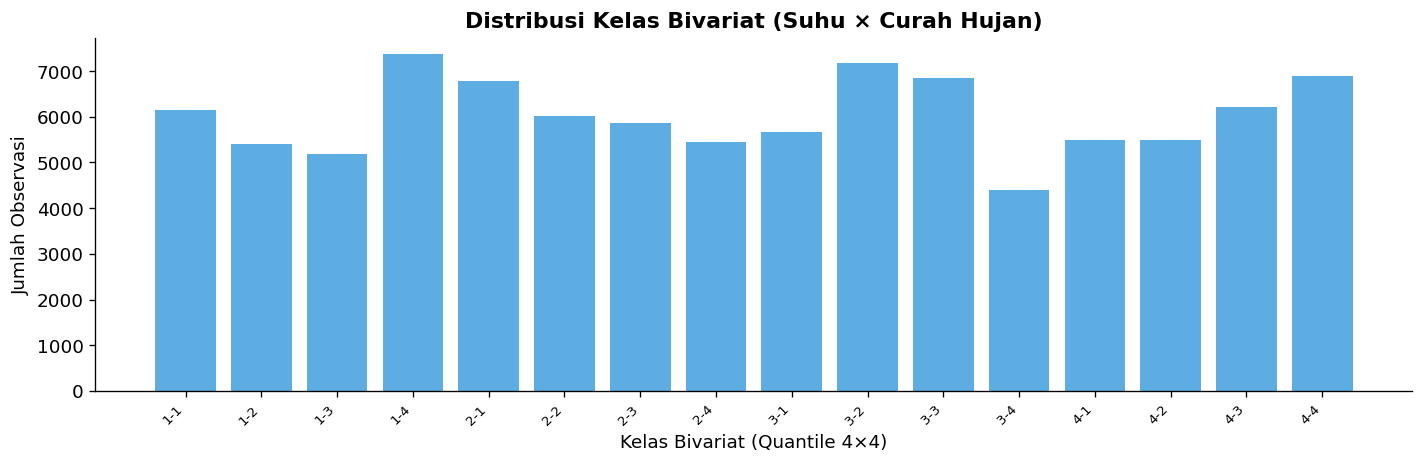

           x         y      suhu  curah_hujan  x_class  y_class bi_class
0  95.229167  5.895833  2.722417      2619.40        2        2      2-2
1  95.270833  5.895833  2.781417      2371.78        3        1      3-1
2  95.312500  5.895833  2.789833      2396.24        3        1      3-1
3  95.354167  5.895833  2.779917      2449.66        3        1      3-1
4  95.229167  5.854167  2.721833      2617.86        2        2      2-2


In [ ]:
# =========================
# 1. FUNGSI BI_CLASS (≈ biscale::bi_class)
# =========================

def bi_class(df, x_col, y_col, dim=4, style="quantile"):
    """Buat label kelas bivariat dari dua variabel numerik."""
    df = df.copy()
    if style == "quantile":
        df["x_class"] = pd.qcut(df[x_col], dim, labels=False, duplicates="drop") + 1
        df["y_class"] = pd.qcut(df[y_col], dim, labels=False, duplicates="drop") + 1
    elif style == "equal":
        df["x_class"] = pd.cut(df[x_col], dim, labels=False) + 1
        df["y_class"] = pd.cut(df[y_col], dim, labels=False) + 1
    df["bi_class"] = (
        df["x_class"].astype(int).astype(str) + "-" +
        df["y_class"].astype(int).astype(str)
    )
    return df

climate_bi = bi_class(climate_df, x_col="suhu", y_col="curah_hujan", dim=4)

# =========================
# 2. PLOT DISTRIBUSI KELAS
# =========================

class_counts = climate_bi["bi_class"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(class_counts.index, class_counts.values, color="#3498db", alpha=0.8)
ax.set_title("Distribusi Kelas Bivariat (Suhu × Curah Hujan)", fontweight="bold")
ax.set_xlabel("Kelas Bivariat (Quantile 4×4)")
ax.set_ylabel("Jumlah Observasi")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout(); plt.show()

print(climate_bi.head())

Klasifikasi bivariat 4×4 ini pada dasarnya membagi kondisi iklim Indonesia menjadi **16 kombinasi** berdasarkan:

* **Suhu**: dari rendah (1) → tinggi (4)
* **Curah hujan**: dari rendah (1) → tinggi (4)

Sehingga setiap grid punya “profil iklim” spesifik.

---

## 🔎 Cara Membaca Kelas

Nilai kelas dibentuk seperti ini:

* **1–4** → curah hujan rendah, suhu dari rendah ke tinggi
* **5–8** → curah hujan agak rendah
* **9–12** → curah hujan tinggi
* **13–16** → curah hujan sangat tinggi

Contoh:

* **Kelas 1** = dingin & kering
* **Kelas 8** = panas & agak kering
* **Kelas 16** = panas & sangat basah

---

## 🌦️ Interpretasi Sederhana

Berikut makna praktisnya:

### 1. Area Kering (kelas 1–4)

* Curah hujan rendah
* Risiko: **kekeringan**, stres air
* Relevansi bank: sektor pertanian & air minum rentan

### 2. Area Transisi (kelas 5–8)

* Curah hujan sedang cenderung rendah
* Risiko moderat
* Biasanya wilayah dengan variabilitas tinggi (tidak stabil)

### 3. Area Basah (kelas 9–12)

* Curah hujan tinggi
* Risiko: **banjir**, longsor (tergantung topografi)
* Relevansi: pembiayaan infrastruktur & properti

### 4. Area Sangat Basah (kelas 13–16)

* Curah hujan sangat tinggi
* Jika dikombinasikan dengan suhu tinggi (kelas 16):

  * Risiko: **banjir ekstrem + tekanan panas**
  * Potensi dampak ke kesehatan & produktivitas

---

## 🌡️ Dimensi Suhu (Horizontal Insight)

* **Suhu rendah (1–2)** → biasanya dataran tinggi
* **Suhu tinggi (3–4)** → dataran rendah / pesisir

Implikasi:

* Suhu tinggi + hujan tinggi → **risiko banjir + heat stress**
* Suhu tinggi + hujan rendah → **risiko kekeringan ekstrem**

---

## 📊 Cara Membaca Grafik Frekuensi

Grafik yang kamu buat menunjukkan:

* **Kelas mana paling dominan**
* Artinya: kondisi iklim “tipikal” Indonesia dalam dataset tersebut

Contoh interpretasi:

* Jika kelas **12–16 dominan** → Indonesia cenderung **panas & basah**
* Jika kelas **4 atau 8 tinggi** → ada area signifikan **panas & kering**

---

## 💼 Insight untuk Risiko Perbankan

Dalam konteks analis risiko iklim:

* **Cluster 13–16** → risiko **physical risk tinggi (flooding)**
* **Cluster 1–4** → risiko **water scarcity**
* **Cluster ekstrem (4, 13, 16)** → kandidat untuk:

  * stress testing portofolio
  * penyesuaian pricing kredit
  * early warning system

---

## 🎯 Ringkasnya

Klasifikasi ini membantu menjawab:

> “Wilayah mana yang panas-kering, dan mana yang panas-basah?”

Sehingga kamu bisa:

* Mengelompokkan risiko iklim secara spasial
* Menghubungkan ke exposure ekonomi (kredit, aset, dll)

---

Kalau kamu mau, langkah berikutnya yang biasanya dilakukan di bank adalah:
👉 **overlay hasil ini dengan data portofolio kredit (by lokasi)** untuk lihat eksposur risiko iklim secara langsung.


## Memetakan data

```
Task:
- Buat peta bivariat dengan skema warna BlueOr (4×4 = 16 warna)
- Overlay batas administrasi menggunakan variabel gdf_adm1 dan gdf_adm0
- Buat legenda bivariat 4×4
- Tampilkan peta dan legenda dalam satu figure

Constraints:
- Gunakan variabel climate_bi dari cell sebelumnya
- Gunakan gdf_adm1 untuk batas provinsi dan gdf_adm0 untuk batas nasional
- Import mcolors (from matplotlib import colors as mcolors) dan
  mpatches (import matplotlib.patches as mpatches) di awal cell jika belum ada
- Tambahkan atribusi: 'Sumber: TerraClimate'
```

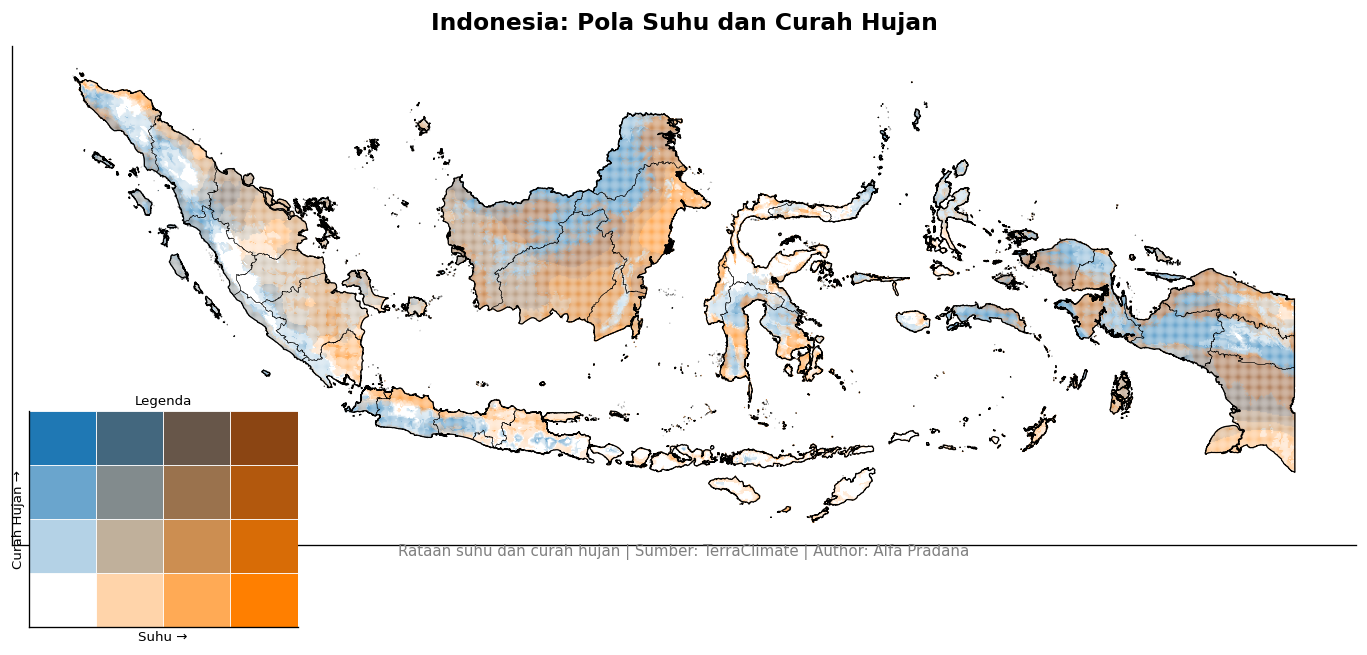


✅ Peta bivariat berhasil dibuat


In [ ]:
# =========================
# 1. DEFINISI PALET BlueOr (16 warna untuk 4×4)
# =========================

# Interpolasi dua gradien: biru (y tinggi) dan oranye (x tinggi)
# Kelas: x = suhu (1–4), y = curah hujan (1–4)
# warna [y-1][x-1]

def make_bivar_palette(dim=4):
    """
    Buat palette bivariat dim×dim dengan interpolasi Biru–Oranye.
    Baris = y-class (curah hujan, bawah=rendah), Kolom = x-class (suhu, kiri=rendah)
    """
    blue   = np.array(mcolors.to_rgb("#1F78B4"))   # Biru (suhu rendah, hujan tinggi)
    orange = np.array(mcolors.to_rgb("#FF7F00"))   # Oranye (suhu tinggi, hujan rendah)
    white  = np.array([1.0, 1.0, 1.0])
    brown  = np.array(mcolors.to_rgb("#8B4513"))   # Coklat (suhu tinggi, hujan tinggi)

    palette = {}
    for xi in range(1, dim + 1):            # suhu
        for yi in range(1, dim + 1):        # curah hujan
            tx = (xi - 1) / (dim - 1)      # 0..1
            ty = (yi - 1) / (dim - 1)      # 0..1
            # Interpolasi bilinear
            color = (
                (1 - tx) * (1 - ty) * white +
                tx       * (1 - ty) * orange +
                (1 - tx) * ty       * blue +
                tx       * ty       * brown
            )
            palette[f"{xi}-{yi}"] = mcolors.to_hex(np.clip(color, 0, 1))
    return palette

bivar_palette = make_bivar_palette(dim=4)

# =========================
# 2. ASSIGN WARNA KE SETIAP PIKSEL
# =========================

climate_bi["color"] = climate_bi["bi_class"].map(bivar_palette).fillna("#cccccc")

# =========================
# 3. PETA BIVARIAT
# =========================

fig = plt.figure(figsize=(14, 6))

# Axes utama (peta)
ax_map = fig.add_axes([0.0, 0.0, 0.80, 1.0])
ax_map.scatter(
    climate_bi["x"], climate_bi["y"],
    c=climate_bi["color"], s=0.3, linewidths=0
)
indo_adm1.plot(ax=ax_map, facecolor="none", edgecolor="black", linewidth=0.25)
indo_adm0.plot(ax=ax_map, facecolor="none", edgecolor="black", linewidth=0.70)

ax_map.set_title("Indonesia: Pola Suhu dan Curah Hujan",
                 fontweight="bold", fontsize=14, pad=10)
ax_map.set_xlabel(""); ax_map.set_ylabel("")
ax_map.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
ax_map.text(0.5, -0.02,
            "Rataan suhu dan curah hujan | Sumber: TerraClimate | Author: Alfa Pradana",
            ha="center", fontsize=9, color="gray",
            transform=ax_map.transAxes)

# Axes legenda (sudut kiri bawah)
dim = 4
ax_leg = fig.add_axes([0.01, 0.04, 0.16, 0.30])
for xi in range(1, dim + 1):
    for yi in range(1, dim + 1):
        col = bivar_palette.get(f"{xi}-{yi}", "#ccc")
        ax_leg.add_patch(mpatches.Rectangle(
            (xi - 1, yi - 1), 1, 1,
            facecolor=col, edgecolor="white", linewidth=0.5
        ))

ax_leg.set_xlim(0, dim); ax_leg.set_ylim(0, dim)
ax_leg.set_xlabel("Suhu →", fontsize=8, labelpad=2)
ax_leg.set_ylabel("Curah Hujan →", fontsize=8, labelpad=2)
ax_leg.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
ax_leg.set_title("Legenda", fontsize=8, pad=4)

plt.savefig("bivariate_map.png", dpi=200, bbox_inches="tight")
plt.show()
print("\n✅ Peta bivariat berhasil dibuat")

Interpretasi peta bivariat (suhu vs curah hujan) di Indonesia perlu dilihat dalam konteks **geografi kepulauan**—karena pola iklim sangat dipengaruhi oleh laut, monsun, dan topografi pulau.

---

## 🌏 Gambaran Besar Indonesia (Sebagai Negara Kepulauan)

Indonesia bukan satu massa daratan, tapi ribuan pulau → implikasinya:

* **Distribusi hujan sangat tidak merata**
* **Efek laut dominan** (maritime climate)
* **Topografi (pegunungan)** sangat menentukan suhu lokal

Akibatnya, peta bivariat biasanya akan membentuk **cluster per pulau**, bukan pola yang seragam nasional.

---

## 🟦🟧 Interpretasi per Wilayah Kepulauan

### 🌴 Sumatra & Kalimantan (Barat Indonesia)

**Dominan: kelas 12–16 (basah–sangat basah, suhu sedang–tinggi)**

* Curah hujan tinggi sepanjang tahun (pengaruh ekuatorial)
* Banyak area **kelas 16 (panas + sangat basah)**

**Makna:**

* Risiko utama: **banjir, genangan, degradasi lahan**
* Relevansi:

  * Perkebunan (sawit) → sensitif terhadap curah hujan ekstrem
  * Infrastruktur → risiko gangguan operasional tinggi

---

### 🏝️ Jawa & Bali

**Dominan: kelas 8–12 (sedang–basah, suhu tinggi)**

* Pola monsun lebih jelas (musim hujan & kemarau)
* Variasi antar wilayah tinggi (utara vs selatan, dataran tinggi vs rendah)

**Makna:**

* Risiko campuran:

  * **Banjir musiman (kelas 10–12)**
  * **Kekeringan musiman (kelas 6–8)**

**Insight penting:**

* Ini wilayah dengan **eksposur ekonomi terbesar**
* Jadi meskipun risikonya “tidak ekstrem”, dampaknya **sistemik**

---

### 🏜️ Nusa Tenggara (NTB & NTT)

**Dominan: kelas 1–6 (kering–semi kering, suhu tinggi)**

* Curah hujan rendah
* Banyak area **kelas 4 (panas + kering)**

**Makna:**

* Risiko utama: **kekeringan kronis**
* Dampak:

  * Pertanian tadah hujan sangat rentan
  * Ketahanan air rendah

**Dalam konteks risiko:**

* Ini adalah hotspot untuk **water stress risk**

---

### 🌊 Sulawesi

**Dominan: campuran kelas 8–14**

* Pola hujan kompleks (tidak sepenuhnya monsun atau ekuatorial)
* Banyak variasi lokal

**Makna:**

* Risiko **terfragmentasi**
* Beberapa area basah → banjir
* Beberapa area lebih kering → kekeringan

**Insight:**

* Sulit digeneralisasi → perlu analisis granular (kabupaten level)

---

### 🌧️ Maluku & Papua

**Dominan: kelas 12–16 (basah–sangat basah)**

* Curah hujan sangat tinggi
* Banyak area suhu sedang (karena elevasi di Papua)

**Makna:**

* Risiko utama:

  * **Banjir ekstrem**
  * **Longsor (Papua pegunungan)**

**Insight:**

* Wilayah ini relatif rendah eksposur ekonomi saat ini,
  tapi penting untuk:

  * proyek infrastruktur
  * pembiayaan berbasis sumber daya alam

---

## 🌡️ Pola Penting yang Terlihat di Peta

### 1. Gradien Barat → Timur

* Barat: **lebih basah**
* Timur: **lebih kering**

👉 Ini adalah pola iklim fundamental Indonesia

---

### 2. Pengaruh Topografi

* Area pegunungan → suhu lebih rendah (kelas suhu 1–2)
* Area pesisir → suhu tinggi (kelas 3–4)

👉 Menjelaskan variasi dalam satu pulau

---

### 3. Dominasi Kelas Ekstrem

Perhatikan:

* **Kelas 16 (panas + sangat basah)** → flood risk tinggi
* **Kelas 4 (panas + kering)** → drought risk tinggi

👉 Dua ekstrem ini biasanya paling relevan untuk risk assessment

---

## 💼 Implikasi untuk Analisis Risiko Perbankan

### 1. Segmentasi Risiko Wilayah

* Barat Indonesia → **flood-driven risk**
* Timur Indonesia → **drought-driven risk**

---

### 2. Prioritas Mitigasi

* Kelas 13–16:

  * perlu stress test untuk banjir
* Kelas 1–4:

  * perlu stress test untuk kekeringan

---

### 3. Overlay dengan Portofolio

Nilai utama peta ini:

> Menghubungkan lokasi debitur dengan tipe risiko iklim

Contoh:

* Kredit sawit di Kalimantan → masuk zona **basah ekstrem**
* Kredit petani di NTT → masuk zona **kering ekstrem**

---

## 🎯 Ringkasan Inti

Peta bivariat menunjukkan bahwa:

* Indonesia **tidak punya satu risiko iklim tunggal**
* Tapi terbagi menjadi:

  * **Barat: terlalu basah**
  * **Timur: terlalu kering**
* Dengan variasi kuat akibat pulau & topografi

---

Kalau kamu mau lanjut ke level yang lebih “bankable”, langkah berikutnya biasanya:
👉 **mapping kelas bivariat → skor risiko (low–medium–high) → dikaitkan dengan exposure kredit**
